In [91]:
import cv2
path = "/data/FullIJCNN2013/"

In [3]:
class BoundingBox:
    def __init__(self, lcol, trow, rcol, brow, cid): #leftCol#;##topRow#;#rightCol#;#bottomRow#;#ClassID#
        self.left_col = int(lcol)
        self.top_row = int(trow)
        self.right_col = int(rcol)
        self.bot_row = int(brow)
        self.class_id = int(cid)
    def __str__(self):
        return f"Left column: {self.left_col}; Top row: {self.top_row}; Right column: {self.right_col}; Bottom row: {self.bot_row}; Class ID:  {self.class_id}"
    def __repr__(self):
        return f"[Left column: {self.left_col}; Top row: {self.top_row}; Right column: {self.right_col}; Bottom row: {self.bot_row}; Class ID:  {self.class_id}]"

In [82]:
bounding_boxes = {}
class_count = {}
lookup = {}
start_line = 40
end_line = 82
with open(path + "ReadMe.txt", 'r') as file:
    lines = file.readlines()
    specific_lines = lines[start_line-1:end_line]
    for line in specific_lines:
        tokens = line.split('=')
        class_id = int(tokens[0].strip())
        class_name = tokens[1].strip()
        lookup[class_id] = class_name
total = 0
with open(path + "gt.txt",'r') as file:
    for line in file:
        tokens = line.strip().split(';')
        cls = int(tokens[5])
        class_count[cls] = class_count.get(cls, 0) + 1
        box = BoundingBox(tokens[1], tokens[2], tokens[3], tokens[4], tokens[5])
        bounding_boxes.setdefault(tokens[0], []).append(box)
        total += 1
print(total)

1213


In [86]:
for cid in lookup:
    if cid in class_count:
        print(f"{cid} - {lookup[cid]} = {class_count[cid] * 100/ total} %")

0 - speed limit 20 (prohibitory) = 0.3297609233305853 %
1 - speed limit 30 (prohibitory) = 6.51277823577906 %
2 - speed limit 50 (prohibitory) = 6.677658697444353 %
3 - speed limit 60 (prohibitory) = 2.4732069249793898 %
4 - speed limit 70 (prohibitory) = 5.605935696619951 %
5 - speed limit 80 (prohibitory) = 4.369332234130256 %
6 - restriction ends 80 (other) = 1.5663643858202803 %
7 - speed limit 100 (prohibitory) = 3.3800494641384997 %
8 - speed limit 120 (prohibitory) = 4.699093157460841 %
9 - no overtaking (prohibitory) = 3.3800494641384997 %
10 - no overtaking (trucks) (prohibitory) = 6.595218466611707 %
11 - priority at next intersection (danger) = 3.1327287716405605 %
12 - priority road (other) = 7.007419620774938 %
13 - give way (other) = 6.842539159109646 %
14 - stop (other) = 2.6380873866446826 %
15 - no traffic both ways (prohibitory) = 1.2366034624896949 %
16 - no trucks (prohibitory) = 0.6595218466611706 %
17 - no entry (other) = 2.390766694146744 %
18 - danger (danger) =

In [97]:
from statistics import mean, median

boxes = [box for image_boxes in bounding_boxes.values() for box in image_boxes]

widths = [box.right_col - box.left_col for box in boxes]
heights = [box.bot_row - box.top_row for box in boxes]
areas = [width * height for width, height in zip(widths, heights)]

print(f"Box count: {len(boxes)}")

print(f"Average width: {mean(widths)}")
print(f"Median width: {median(widths)}")

print(f"Average height: {mean(heights)}")
print(f"Median height: {median(heights)}")

print(f"Average surface area: {mean(areas)}")
print(f"Median surface area: {median(areas)}")
print(f"Minimum surface area: {min(areas)}")
print(f"Maximum surface area: {max(areas)}")

Box count: 1213
Average width: 43.59934047815334
Median width: 38
Average height: 42.86232481450948
Median height: 37
Average surface area: 2321.9958779884582
Median surface area: 1369
Minimum surface area: 256
Maximum surface area: 15376


In [98]:
import numpy as np

for name, values in {
    "width": widths,
    "height": heights,
    "area": areas,
}.items():
    print(name)
    print("min:", min(values))
    print("25th percentile:", np.percentile(values, 25))
    print("median:", median(values))
    print("90th percentile:", np.percentile(values, 90))
    print("mean:", mean(values))
    print("max:", max(values))

width
min: 16
25th percentile: 28.0
median: 38
90th percentile: 73.79999999999995
mean: 43.59934047815334
max: 127
height
min: 16
25th percentile: 28.0
median: 37
90th percentile: 71.0
mean: 42.86232481450948
max: 128
area
min: 256
25th percentile: 784.0
median: 1369
90th percentile: 5236.799999999997
mean: 2321.9958779884582
max: 15376


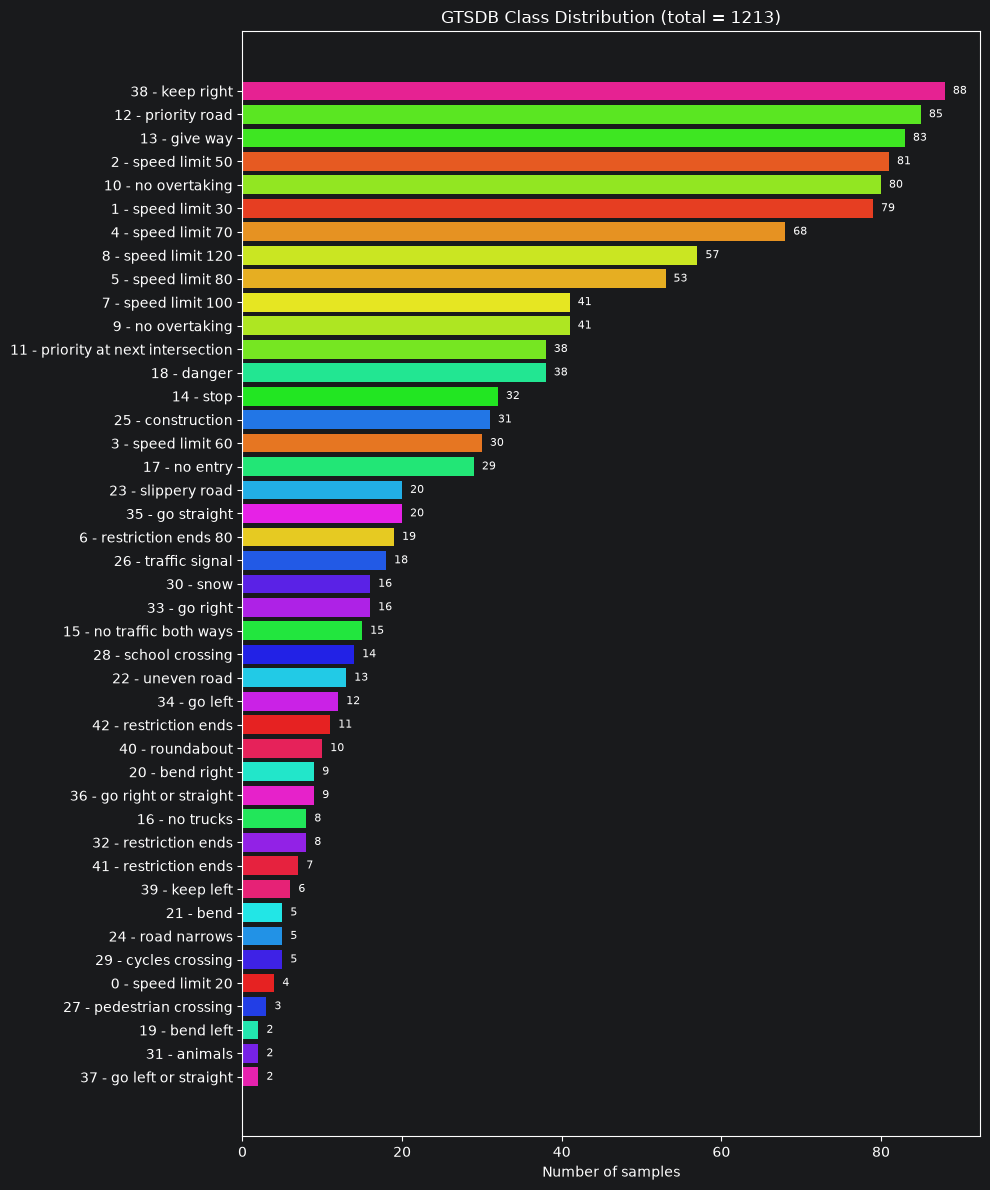

In [100]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# build data sorted by count descending
data = sorted(
    ((cid, lookup[cid], class_count[cid]) for cid in lookup if cid in class_count),
    key=lambda x: x[2],
    reverse=True
)

cids   = [d[0] for d in data]
names  = [d[1] for d in data]
counts = [d[2] for d in data]
labels = [f"{cid} - {name.split(' (')[0]}" for cid, name in zip(cids, names)]

# hue = id normalized to [0, 360), full saturation/value for vivid distinct colors
colors = [mcolors.hsv_to_rgb((cid * 360/42 / 360, 0.85, 0.9)) for cid in cids]

fig, ax = plt.subplots(figsize=(10, 12))
bars = ax.barh(labels, counts, color=colors)
ax.invert_yaxis()
ax.set_xlabel("Number of samples")
ax.set_title(f"GTSDB Class Distribution (total = {total})")

for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
             str(count), va='center', fontsize=8)

plt.tight_layout()
plt.savefig("../plots/class_distribution.png", dpi=150)
plt.show()

In [99]:
import random

image_ids = list(bounding_boxes.keys())
rand_id = random.choice(image_ids)
image_path = str(rand_id).zfill(5)

image = cv2.imread(path + image_path)
height, width = image.shape[:2]
print(height, width)
for box in bounding_boxes[image_path]:
    top_left = (box.left_col, box.top_row)
    bot_right = (box.right_col, box.bot_row)
    color = (0, 255, 0)
    thickness = 1
    cv2.rectangle(image, top_left, bot_right, color, thickness)
cv2.imshow(f"{image_path}", image)
cv2.waitKey(0)
cv2.destroyAllWindows()

800 1360
